In [1]:
from data.weather_fetch import write_query_config, fetch_and_save
from data.preprocess_311 import preprocess_311

In [3]:
import os
outs = preprocess_311(['data/csv_data/' + f for f in os.listdir('data/csv_data')])

Reading data/csv_data/311_City_Service_Requests_in_2010.csv …
Reading data/csv_data/311_City_Service_Requests_in_2011.csv …
Reading data/csv_data/311_City_Service_Requests_in_2015.csv …
Reading data/csv_data/311_City_Service_Requests_in_2017.csv …
Reading data/csv_data/311_City_Service_Requests_in_2022.csv …
Reading data/csv_data/311_City_Service_Requests_in_2024.csv …
Reading data/csv_data/311_City_Service_Requests_in_2025.csv …
Reading data/csv_data/311_City_Service_Requests_in_2026.csv …
Reading data/csv_data/311_City_Service_Requests_in__2009.csv …
Reading data/csv_data/311_City_Service_Requests_in__2012.csv …
Reading data/csv_data/311_City_Service_Requests_in__2013.csv …
Reading data/csv_data/311_City_Service_Requests_in__2014.csv …
Reading data/csv_data/311_City_Service_Requests_in__2016.csv …
Reading data/csv_data/311_City_Service_Requests_in__2018.csv …
Reading data/csv_data/311_City_Service_Requests_in__2019.csv …
Reading data/csv_data/311_City_Service_Requests_in__2020.csv …


In [4]:
# inspect outs 
wards = [f'ward{i}' for i in range(1, 9)]
for ward in wards: 
    if ward != 'ward3':
        continue
    print(f"Processing {ward}")
    lat, lon = outs[ward][1], outs[ward][2]
    # write a query config 
    query_config = write_query_config(ward, lat, lon, '2010-01-01', '2025-12-31')
    _, _ = fetch_and_save(query_config)

Processing ward3
Config written → data/weather_query_configs/weather_ward3_20100101_20251231.json
Fetching from Open-Meteo API for ward3 …
  Coordinates : (38.94136141075848, -77.0780627123208)
  Date range  : 2010-01-01 → 2025-12-31
Saved  data/weather_cache/weather_ward3_20100101_20251231.parquet  (140,256 rows)
Saved  data/weather_cache/weather_ward3_20100101_20251231_metadata.json


In [6]:
# visualize the entire pothole requests data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_parquet('data/311_data/ward3_potholes_20090820_20260503.parquet')
df.head()

,ADDDATE,WARD,SERVICECODEDESCRIPTION
0,2010-03-14 16:27:58+00:00,Ward 3,Pothole
1,2010-03-22 16:56:31+00:00,Ward 3,Pothole
2,2010-08-26 13:28:25+00:00,Ward 3,Pothole
3,2010-08-19 10:45:31+00:00,Ward 3,Pothole
4,2010-10-28 15:29:20+00:00,Ward 3,Pothole


In [7]:
len(pd.to_datetime(df['ADDDATE']).dt.date.unique())

3850

Processing data/311_data/ward3_potholes_20090820_20260503.parquet


Text(0.5, 1.0, 'Pothole Requests Over Time')

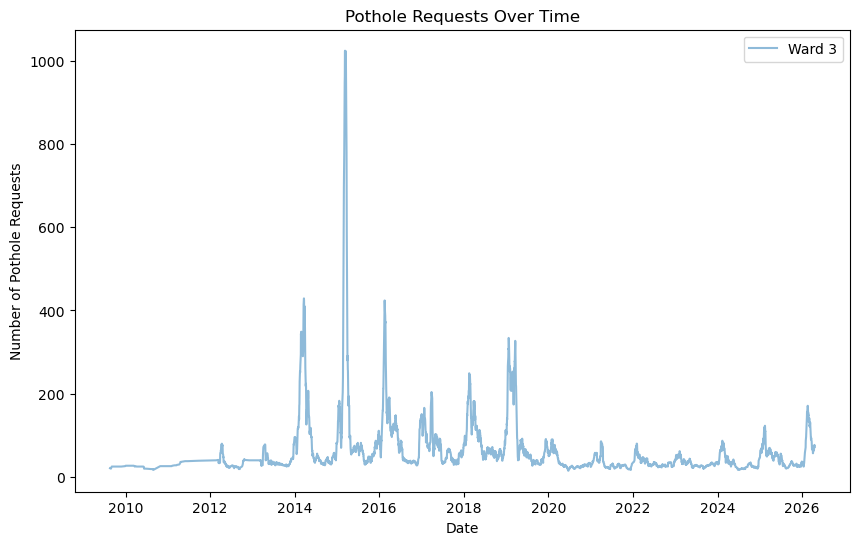

In [8]:
# ward_parquets = [f'data/311_data/ward{i}_potholes_20210101_20251231.parquet' for i in range(1, 9)]
ward_parquets = [f'data/311_data/ward{i}_potholes_20090820_20260503.parquet' for i in range(1, 9)]
def process_pothole_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("ADDDATE")
    df['DATE'] = pd.to_datetime(df['ADDDATE']).dt.date
    potholes_daily = df.groupby('DATE').size()
    return potholes_daily

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
for idx, f in enumerate(ward_parquets):
    ward_name = f'Ward {idx + 1}'
    if ward_name != 'Ward 3':
        continue
    print(f"Processing {f}")
    df = pd.read_parquet(f)
    potholes_daily = process_pothole_data(df)
    ax.plot(potholes_daily.index, potholes_daily.rolling(15).sum().shift(-14), 
            label=ward_name, alpha=0.5)
ax.legend()
plt.xlabel('Date')
plt.ylabel('Number of Pothole Requests')
plt.title('Pothole Requests Over Time')

Text(0.5, 1.0, 'Pothole Requests Over Time')

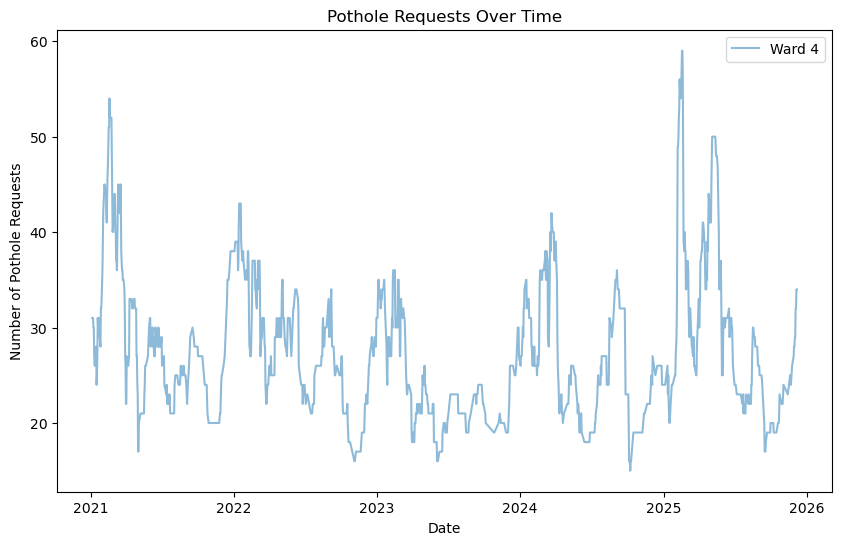

In [9]:
# ward 3 trend 
idx = 3 

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ward_name = f'Ward {idx + 1}'
df = pd.read_parquet(f)
potholes_daily = process_pothole_data(df)
ax.plot(potholes_daily.index, potholes_daily.rolling(15).sum().shift(-14), 
        label=ward_name, alpha=0.5)
ax.legend()
plt.xlabel('Date')
plt.ylabel('Number of Pothole Requests')
plt.title('Pothole Requests Over Time')